# **NLP SEMANTIC SEARCH PIPELINE**

Step 1 : Install and Import

In [ ]:
!pip install datasets gensim

import re
import nltk
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from gensim.models import Word2Vec

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

Step 2 : LoadData

In [ ]:
dataset = load_dataset("imdb")
texts = dataset['train']['text'][:500]

print(texts[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, eve

Step 3 : Clean text

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

cleaned = [clean_text(t) for t in texts]

print(cleaned[0])

i rented i am curiousyellow from my video store because of all the controversy that surrounded it when it was first released in  i also heard that at first it was seized by us customs if it ever tried to enter this country therefore being a fan of films considered controversial i really had to see this for myselfbr br the plot is centered around a young swedish drama student named lena who wants to learn everything she can about life in particular she wants to focus her attentions to making some sort of documentary on what the average swede thought about certain political issues such as the vietnam war and race issues in the united states in between asking politicians and ordinary denizens of stockholm about their opinions on politics she has sex with her drama teacher classmates and married menbr br what kills me about i am curiousyellow is that  years ago this was considered pornographic really the sex and nudity scenes are few and far between even then its not shot like some cheaply

Step 4 : Tokenization

In [ ]:
tokenized = [word_tokenize(t) for t in cleaned]

print(tokenized[0])

['i', 'rented', 'i', 'am', 'curiousyellow', 'from', 'my', 'video', 'store', 'because', 'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when', 'it', 'was', 'first', 'released', 'in', 'i', 'also', 'heard', 'that', 'at', 'first', 'it', 'was', 'seized', 'by', 'us', 'customs', 'if', 'it', 'ever', 'tried', 'to', 'enter', 'this', 'country', 'therefore', 'being', 'a', 'fan', 'of', 'films', 'considered', 'controversial', 'i', 'really', 'had', 'to', 'see', 'this', 'for', 'myselfbr', 'br', 'the', 'plot', 'is', 'centered', 'around', 'a', 'young', 'swedish', 'drama', 'student', 'named', 'lena', 'who', 'wants', 'to', 'learn', 'everything', 'she', 'can', 'about', 'life', 'in', 'particular', 'she', 'wants', 'to', 'focus', 'her', 'attentions', 'to', 'making', 'some', 'sort', 'of', 'documentary', 'on', 'what', 'the', 'average', 'swede', 'thought', 'about', 'certain', 'political', 'issues', 'such', 'as', 'the', 'vietnam', 'war', 'and', 'race', 'issues', 'in', 'the', 'united', 'states', 'i

Step 5 : Remove Stopwords

In [ ]:
stop_words = set(stopwords.words('english'))

filtered = [[w for w in t if w not in stop_words] for t in tokenized]

print(filtered[0])

['rented', 'curiousyellow', 'video', 'store', 'controversy', 'surrounded', 'first', 'released', 'also', 'heard', 'first', 'seized', 'us', 'customs', 'ever', 'tried', 'enter', 'country', 'therefore', 'fan', 'films', 'considered', 'controversial', 'really', 'see', 'myselfbr', 'br', 'plot', 'centered', 'around', 'young', 'swedish', 'drama', 'student', 'named', 'lena', 'wants', 'learn', 'everything', 'life', 'particular', 'wants', 'focus', 'attentions', 'making', 'sort', 'documentary', 'average', 'swede', 'thought', 'certain', 'political', 'issues', 'vietnam', 'war', 'race', 'issues', 'united', 'states', 'asking', 'politicians', 'ordinary', 'denizens', 'stockholm', 'opinions', 'politics', 'sex', 'drama', 'teacher', 'classmates', 'married', 'menbr', 'br', 'kills', 'curiousyellow', 'years', 'ago', 'considered', 'pornographic', 'really', 'sex', 'nudity', 'scenes', 'far', 'even', 'shot', 'like', 'cheaply', 'made', 'porno', 'countrymen', 'mind', 'find', 'shocking', 'reality', 'sex', 'nudity', '

Step 6 : Lemmatization

In [ ]:
lemmatizer = WordNetLemmatizer()

lemmatized = [[lemmatizer.lemmatize(w) for w in t] for t in filtered]

print(lemmatized[0])

['rented', 'curiousyellow', 'video', 'store', 'controversy', 'surrounded', 'first', 'released', 'also', 'heard', 'first', 'seized', 'u', 'custom', 'ever', 'tried', 'enter', 'country', 'therefore', 'fan', 'film', 'considered', 'controversial', 'really', 'see', 'myselfbr', 'br', 'plot', 'centered', 'around', 'young', 'swedish', 'drama', 'student', 'named', 'lena', 'want', 'learn', 'everything', 'life', 'particular', 'want', 'focus', 'attention', 'making', 'sort', 'documentary', 'average', 'swede', 'thought', 'certain', 'political', 'issue', 'vietnam', 'war', 'race', 'issue', 'united', 'state', 'asking', 'politician', 'ordinary', 'denizen', 'stockholm', 'opinion', 'politics', 'sex', 'drama', 'teacher', 'classmate', 'married', 'menbr', 'br', 'kill', 'curiousyellow', 'year', 'ago', 'considered', 'pornographic', 'really', 'sex', 'nudity', 'scene', 'far', 'even', 'shot', 'like', 'cheaply', 'made', 'porno', 'countryman', 'mind', 'find', 'shocking', 'reality', 'sex', 'nudity', 'major', 'staple'

Step 7 : Vocabulary

In [ ]:
vocab = set()

for t in lemmatized:
    vocab.update(t)

print("Vocabulary size:", len(vocab))

Vocabulary size: 10947


Step 8 : TF-IDF

In [ ]:
joined = [" ".join(t) for t in lemmatized]

vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform(joined)

print(tfidf.shape)

(500, 10927)


Step 9 : WORD2VEC

In [ ]:
model = Word2Vec(sentences=lemmatized, vector_size=100, window=5, min_count=1)

print(model.wv["good"][:10])

[-0.3278277   0.5226612   0.13922442  0.23722497  0.2705446  -0.92055845
  0.11673728  1.3390287  -0.34890264 -0.28703162]


Step 10 : Sentence Embeddings

In [ ]:
def sent_vec(sentence):
    vecs = [model.wv[w] for w in sentence if w in model.wv]
    if len(vecs) == 0:
        return np.zeros(100)
    return np.mean(vecs, axis=0)

sent_vectors = [sent_vec(s) for s in lemmatized]

Step 11 : Similarity Search

In [ ]:
query = sent_vectors[0]

sims = cosine_similarity([query], sent_vectors)[0]

top = sims.argsort()[-5:][::-1]

for i in top:
    print("\nTEXT:", texts[i][:100])
    print("SIM:", sims[i])


TEXT: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it w
SIM: 1.0

TEXT: It figures this is a French film, LOL, with the emphasis on young girls with much older men...why is
SIM: 0.9999949

TEXT: Oh, brother...after hearing about this ridiculous film for umpteen years all I can think of is that 
SIM: 0.9999947

TEXT: WARNING: This review contains SPOILERS. Do not read if you don't want some points revealed to you be
SIM: 0.99999464

TEXT: Well, where to begin? I guess I can start with the general complaint regarding the way in which this
SIM: 0.9999945


Step 12 : Visualisation

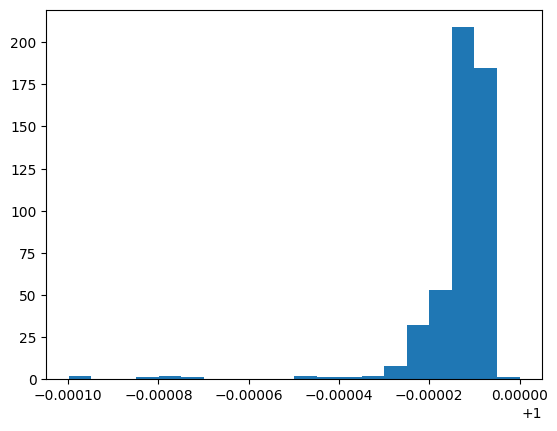

In [ ]:
plt.hist(sims, bins=20)
plt.show()

Step 13 : Final Result

In [ ]:
print("Query:", texts[0][:100])
print("\nMost similar:", texts[top[1]][:100])
print("\nScore:", sims[top[1]])

Query: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it w

Most similar: It figures this is a French film, LOL, with the emphasis on young girls with much older men...why is

Score: 0.9999949
